## Task 2 — Spark (File Format + Distributed Processing)

### Activity 1 — HDFS-like Behavior (Spark Local)

#### Environment Configuration Checking

In [2]:
import sys
import os
print(os.environ.get("JAVA_HOME")) #Required JDK Version 11 for PySpark
print(sys.executable) #Required Python Stable Version for PySpark is Python 3.10 or 3.11

C:\Program Files\Java\jdk-11
c:\Users\RUMAN\Downloads\msc\big-data-analytics-lab\big-data\Scripts\python.exe


#### Force Java 11 Inside Python if Not Working Environment Variable

In [3]:
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-11"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

In [ ]:
from pyspark.sql import SparkSession
from datetime import datetime
import time
import os

# Start time
start_time = datetime.now()
print("Start Time:", start_time.strftime("%Y-%m-%d %H:%M:%S"))
start = time.time()

# BUILD THE SESSION
# .appName() ➡️ Sets a name for the application, which appears in the Spark Web UI
# .master()  ➡️ Defines the cluster manager to connect to (e.g., local for a single core, local[*] for all cores, or a cluster URL).
# .getOrCreate()  ➡️ Returns an existing session if one is already running, or creates a new one if not

spark = SparkSession.builder \
    .appName("Task2_Lab") \
    .master("local[*]") \
    .getOrCreate()

file_path = "../dataset/nyc_taxi.csv"

print("Checking file...")
if not os.path.exists(file_path):
    print("File not found ❌")
    exit()

print("Testing with small sample...")

df = spark.read.csv(file_path, header=True, inferSchema=True)

df.limit(100).show(5)

print("Test successful ✅")
print("Running full data...")

# full execution
print("Partitions:", df.rdd.getNumPartitions())
print("Row count:", df.count())
# print("Row count:", df.limit(10000).count())  # safer option

# End time AFTER full execution
end = time.time()
end_time = datetime.now()

print("End Time:", end_time.strftime("%Y-%m-%d %H:%M:%S"))
print("Time Taken:", round(end - start, 2), "seconds")

Start Time: 2026-04-04 18:12:55


#### Observation:
- Data automatically split into partitions
- Simulates HDFS blocks

### Activity 2 — CSV → Parquet Conversion

####  Step 1 — Read CSV

In [ ]:
df = spark.read.csv("data.csv", header=True, inferSchema=True)

#### Step 2 — Write Parquet

In [ ]:
df.write.parquet("data_parquet")

#### Step 3 — Compare Size & Performance

| Format  | Size   | Speed  |
| ------- | ------ | ------ |
| CSV     | Large  | Slow   |
| JSON    | Medium | Slower |
| Parquet | Small  | Fast   |

#### Observation:

- Parquet uses compression + column storage
- Faster read time
- Less disk usage


#### Column Pruning Example
Only required column is read-> fater

In [ ]:
df.select("fare_amount").show()

#### Final Conclusion
- Spark ✔ distributed processing
- Handles large data efficiently
- Parquet ✔ best format
- Faster + compressed + optimized

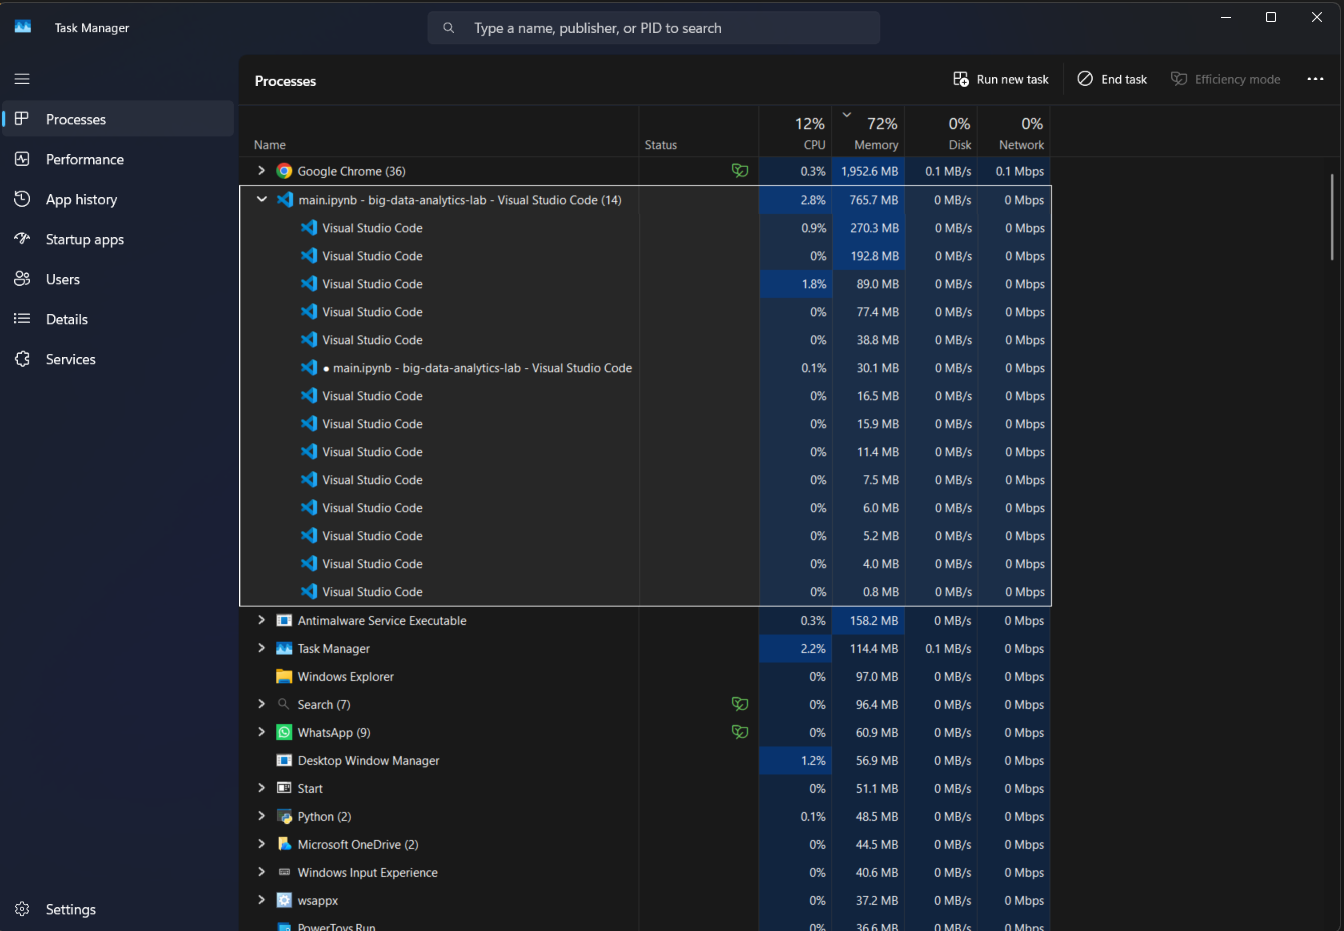

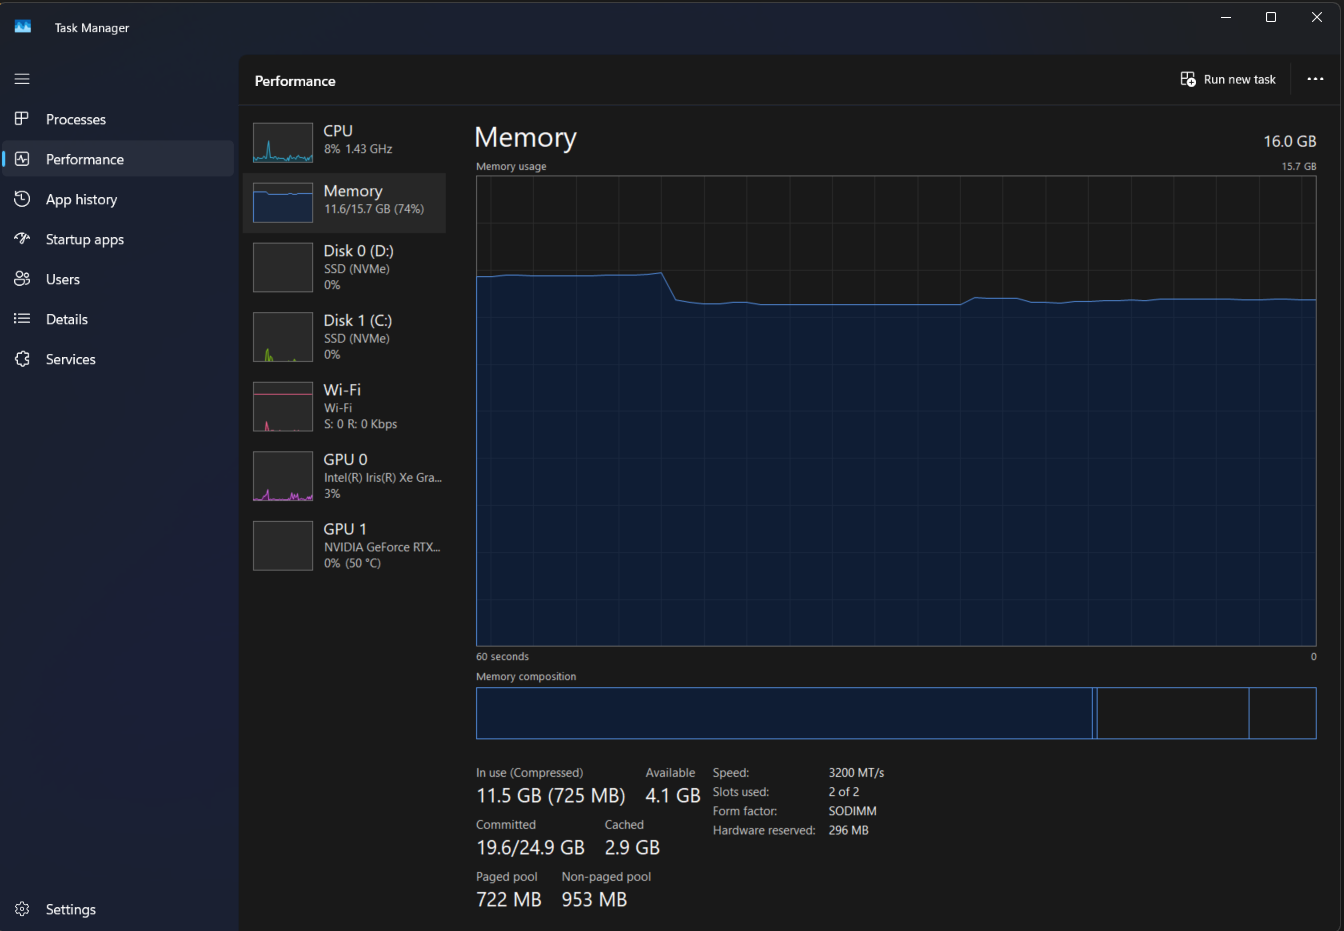

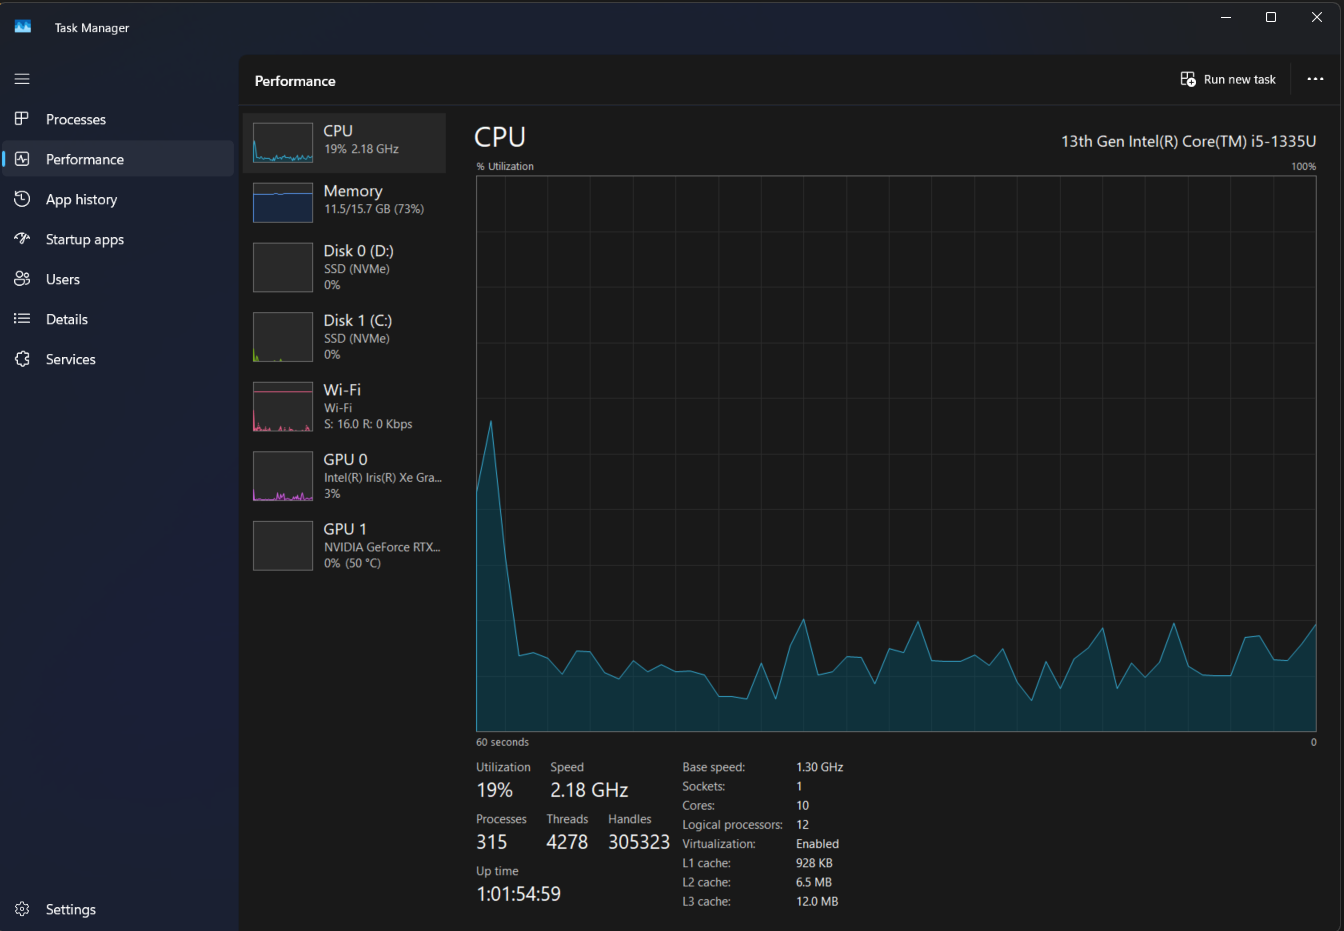

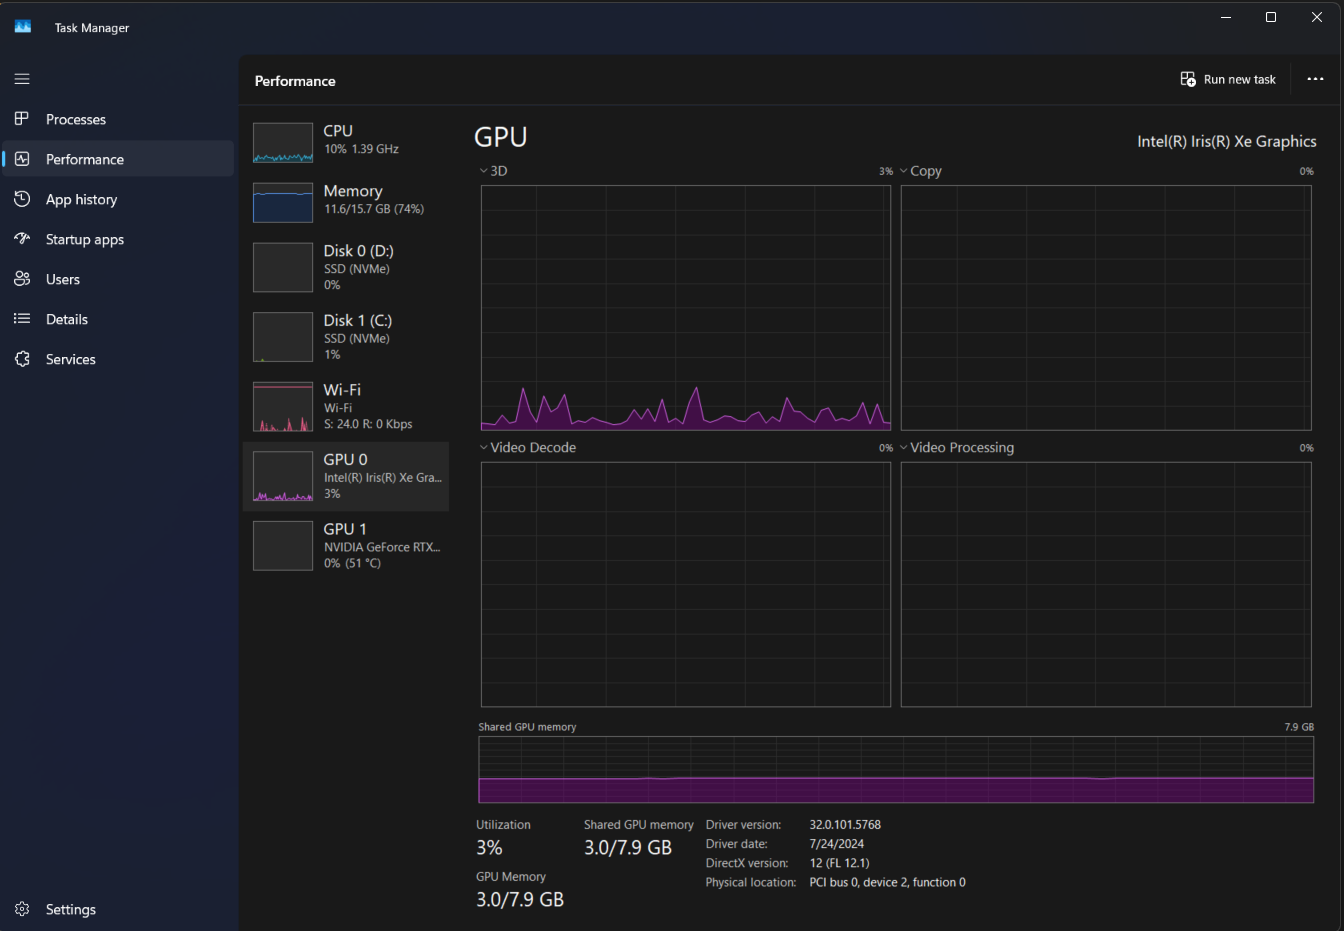